# GCON Model Training And Evaluation


## 1. Setup

Define paths, constants, model grids, and common settings.

In [1]:
from pathlib import Path
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 120)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'train_NBFO_IB':
    PROJECT_ROOT = PROJECT_ROOT.parent

NBFO_DIR = PROJECT_ROOT / 'train_NBFO_IB'
PROCESSED_DIR = NBFO_DIR / 'processed_data'
OUTPUT_DIR = NBFO_DIR / 'saved_models'
MODEL_DIR = OUTPUT_DIR
INPUT_PATH = PROCESSED_DIR / 'gcon_model_input.parquet'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SAVED_MODEL_PATH = MODEL_DIR / 'selected_xgboost_model.joblib'
SAVED_MODEL_NAME = None  # If None, infer from SAVED_MODEL_PATH.
# Load the saved selected model when available; set False manually to force retraining.
LOAD_SAVED_MODEL = SAVED_MODEL_PATH.exists()
EXCLUDED_FEATURE_PREFIXES = ('LOG_', 'STAFF_', 'SMS_', 'EB_REGISTER_CHANNEL_')

HORIZON = 2
RANDOM_STATE = 42
RANKING_K_VALUES = [1, 2, 3]
LIFT_TOP_PCTS = [0.01, 0.05, 0.10, 0.20]
CALIBRATION_BINS = 10
CALIBRATE_SELECTED_MODEL = True
CALIBRATION_METHOD = 'sigmoid'
CALIBRATION_N_SPLITS = 5
SHAP_SAMPLE_SIZE = 5000
RANDOM_SEARCH_N_JOBS = 1  # Keep CV fits sequential to avoid copying large X_train into many worker processes.
RANDOM_SEARCH_N_ITER = 12
MODEL_N_JOBS = -1

ID_COLS = ['CUSTOMER_NUMBER', 'PRODUCT_CODE', 'PRODUCT_NAME', 'MONTH']
TARGET_COL = 'SUBSCRIPTION'

TRAIN_MONTH_NUMBERS = list(range(1, 9))
VALIDATION_MONTH_NUMBERS = [9]
TEST_MONTH_NUMBERS = [10]

## 2. I/O Helpers

Use CSV fallbacks only when a file is locked by another process.

In [2]:
def safe_to_csv(df, path):
    path = Path(path)
    try:
        df.to_csv(path, index=False)
        print('saved', path, df.shape)
    except PermissionError:
        fallback = path.with_name(f'{path.stem}_new{path.suffix}')
        df.to_csv(fallback, index=False)
        print('permission denied for', path, '| saved fallback', fallback, df.shape)


def save_table(df, path_stem):
    parquet_path = OUTPUT_DIR / f'{path_stem}.parquet'
    csv_path = OUTPUT_DIR / f'{path_stem}.csv'
    try:
        df.to_parquet(parquet_path, index=False)
        print('saved', parquet_path, df.shape)
    except Exception as exc:
        df.to_csv(csv_path, index=False)
        print('saved', csv_path, df.shape, '| parquet failed:', type(exc).__name__)

## 3. Load Model Input

Read the single parquet created by `EDA.ipynb` and identify model features.

In [3]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(f'Missing {INPUT_PATH}. Run EDA.ipynb first.')

model_input = pd.read_parquet(INPUT_PATH)
model_input['MONTH'] = pd.to_datetime(model_input['MONTH'], errors='coerce').dt.to_period('M').dt.to_timestamp('M')
model_input = model_input.dropna(subset=['CUSTOMER_NUMBER', 'MONTH', TARGET_COL]).copy()
model_input = model_input.sort_values(['MONTH', 'CUSTOMER_NUMBER', 'PRODUCT_CODE']).reset_index(drop=True)

feature_cols = [
    c for c in model_input.columns
    if c not in ID_COLS + [TARGET_COL]
    and not c.startswith(EXCLUDED_FEATURE_PREFIXES)
]

print('model_input:', model_input.shape)
print('features:', len(feature_cols))
print('months:', model_input['MONTH'].min(), model_input['MONTH'].max())
display(model_input.groupby(model_input['MONTH'].dt.month)[TARGET_COL].agg(rows='count', positives='sum', positive_rate='mean'))

model_input: (1795423, 158)
features: 153
months: 2019-01-31 00:00:00 2019-10-31 00:00:00


,rows,positives,positive_rate
MONTH,,,
1,31177,2188,0.070180
2,45895,2307,0.050267
3,76330,4087,0.053544
4,109896,4720,0.042950
5,150475,6276,0.041708
6,186744,6630,0.035503
7,229304,8186,0.035699
8,277587,8843,0.031857
9,316514,8302,0.026229


## 4. Time-Based Split

Use train = months 1-8, validation = month 9, test = month 10. Later months are excluded.

In [4]:
month_number = model_input['MONTH'].dt.month
train_df = model_input[month_number.isin(TRAIN_MONTH_NUMBERS)].copy()
validation_df = model_input[month_number.isin(VALIDATION_MONTH_NUMBERS)].copy()
test_df = model_input[month_number.isin(TEST_MONTH_NUMBERS)].copy()
excluded_df = model_input[~month_number.isin(TRAIN_MONTH_NUMBERS + VALIDATION_MONTH_NUMBERS + TEST_MONTH_NUMBERS)].copy()

if train_df.empty or validation_df.empty or test_df.empty:
    raise ValueError('One of train/validation/test splits is empty. Check available MONTH values and split month numbers.')

TEMPORAL_BASE_COLS = [
    'ACTIVITY_NAME_NUNIQUE',
    'ACTIVITY_RECORDS',
    'SPTC_COUNT',
    'TOTAL_DEPOSIT_ACCTS',
    'TOTAL_DEPOSIT_BALANCE',
    'TRANS_AMOUNT_SUM',
]
OWN_COLS = ['OWN_CURRENT_ACCOUNT', 'OWN_TERM_DEPOSIT', 'OWN_CREDIT_CARD', 'OWN_DEBIT_CARD', 'OWN_LENDING']
PRODUCT_TO_OWN = {
    'CURRENT_ACCOUNT': 'OWN_CURRENT_ACCOUNT',
    'TERM_DEPOSIT': 'OWN_TERM_DEPOSIT',
    'CREDIT_CARD': 'OWN_CREDIT_CARD',
    'DEBIT_CARD': 'OWN_DEBIT_CARD',
    'LENDING': 'OWN_LENDING',
}


def add_temporal_features_after_split(split_frames):
    """Create lag/diff/rolling features after split using past months only."""
    combined = pd.concat(
        [frame.assign(_SPLIT_NAME=split_name) for split_name, frame in split_frames.items()],
        ignore_index=True,
    ).sort_values(['MONTH', 'CUSTOMER_NUMBER', 'PRODUCT_CODE']).reset_index(drop=True)

    activity_count_cols = sorted([
        c for c in combined.columns
        if c.startswith('ACTIVITY_TYPE_COUNT_')
        and not c.endswith(('_SHARE', '_LAST_90D', '_AVG_90D'))
    ])
    product_count_specs = {
        'CURRENT_ACCOUNT': 'COUNT_CA_ACCT',
        'TERM_DEPOSIT': 'COUNT_TD_ACCT',
        'CREDIT_CARD': 'COUNT_CREDITCARD',
        'DEBIT_CARD': 'COUNT_DEBITCARD',
        'LENDING': 'COUNT_OF_LOAN',
    }
    rolling_source_cols = [
        'TRANS_ACTIVE_DAYS',
        'ACTIVITY_ACTIVE_DAYS',
        *activity_count_cols,
        *product_count_specs.values(),
        *OWN_COLS,
    ]
    customer_month_feature_cols = list(dict.fromkeys([
        *TEMPORAL_BASE_COLS,
        *[col for col in rolling_source_cols if col in combined.columns],
    ]))
    missing = [col for col in TEMPORAL_BASE_COLS if col not in combined.columns]
    if missing:
        raise KeyError(f'Missing temporal base columns: {missing}')

    customer_month = (
        combined[['CUSTOMER_NUMBER', 'MONTH'] + customer_month_feature_cols]
        .drop_duplicates(['CUSTOMER_NUMBER', 'MONTH'])
        .sort_values(['CUSTOMER_NUMBER', 'MONTH'])
        .reset_index(drop=True)
    )
    grouped = customer_month.groupby('CUSTOMER_NUMBER', sort=False)
    for col in TEMPORAL_BASE_COLS:
        lag = grouped[col].shift(1).fillna(0)
        customer_month[f'{col}_LAG1'] = lag
        customer_month[f'{col}_DIFF1'] = customer_month[col] - lag
        # Rolling uses shift(1), so month T only sees months before T, never the current/future month.
        customer_month[f'{col}_ROLL3_MEAN'] = (
            grouped[col]
            .shift(1)
            .groupby(customer_month['CUSTOMER_NUMBER'], sort=False)
            .rolling(3, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
            .fillna(0)
        )

    temporal_cols = [
        f'{col}_{suffix}'
        for col in TEMPORAL_BASE_COLS
        for suffix in ['LAG1', 'DIFF1', 'ROLL3_MEAN']
    ]

    rolling_sum_specs = {
        'ACTIVE_DAYS_LAST_90D': 'TRANS_ACTIVE_DAYS',
        'ACTIVITY_COUNT_LAST_90D': 'ACTIVITY_RECORDS',
        'ACTIVITY_ACTIVE_DAYS_LAST_90D': 'ACTIVITY_ACTIVE_DAYS',
        'TOTAL_TRANSACTION_AMOUNT_90D': 'TRANS_AMOUNT_SUM',
    }
    rolling_mean_specs = {
        'AVG_BALANCE_90D': 'TOTAL_DEPOSIT_BALANCE',
    }
    for new_col, source_col in rolling_sum_specs.items():
        customer_month[new_col] = (
            grouped[source_col]
            .shift(1)
            .groupby(customer_month['CUSTOMER_NUMBER'], sort=False)
            .rolling(3, min_periods=1)
            .sum()
            .reset_index(level=0, drop=True)
            .fillna(0)
        )

    for new_col, source_col in rolling_mean_specs.items():
        customer_month[new_col] = (
            grouped[source_col]
            .shift(1)
            .groupby(customer_month['CUSTOMER_NUMBER'], sort=False)
            .rolling(3, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
            .fillna(0)
        )

    customer_month['ACTIVITY_RECORDS_PER_ACTIVE_DAY_90D'] = np.where(
        customer_month['ACTIVITY_ACTIVE_DAYS_LAST_90D'] > 0,
        customer_month['ACTIVITY_COUNT_LAST_90D'] / customer_month['ACTIVITY_ACTIVE_DAYS_LAST_90D'],
        0,
    )

    for col in activity_count_cols:
        customer_month[f'{col}_LAST_90D'] = (
            grouped[col]
            .shift(1)
            .groupby(customer_month['CUSTOMER_NUMBER'], sort=False)
            .rolling(3, min_periods=1)
            .sum()
            .reset_index(level=0, drop=True)
            .fillna(0)
        )
        customer_month[f'{col}_AVG_90D'] = (
            grouped[col]
            .shift(1)
            .groupby(customer_month['CUSTOMER_NUMBER'], sort=False)
            .rolling(3, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
            .fillna(0)
        )

    for product_name, source_col in product_count_specs.items():
        customer_month[f'{product_name}_COUNT_LAST_90D'] = (
            grouped[source_col]
            .shift(1)
            .groupby(customer_month['CUSTOMER_NUMBER'], sort=False)
            .rolling(3, min_periods=1)
            .sum()
            .reset_index(level=0, drop=True)
            .fillna(0)
        )
        customer_month[f'{product_name}_COUNT_AVG_90D'] = (
            grouped[source_col]
            .shift(1)
            .groupby(customer_month['CUSTOMER_NUMBER'], sort=False)
            .rolling(3, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
            .fillna(0)
        )

    product_open_cols = []
    for product_name, own_col in PRODUCT_TO_OWN.items():
        open_col = f'PRODUCT_OPEN_FLAG_{product_name}'
        product_open_cols.append(open_col)
        customer_month[open_col] = grouped[own_col].diff().gt(0).astype('int8')
    customer_month['PRODUCT_TRANSITION_COUNT_LAST_90D'] = (
        customer_month.groupby('CUSTOMER_NUMBER', sort=False)[product_open_cols]
        .shift(1)
        .groupby(customer_month['CUSTOMER_NUMBER'], sort=False)
        .rolling(3, min_periods=1)
        .sum()
        .reset_index(level=0, drop=True)
        .sum(axis=1)
        .fillna(0)
    )
    customer_month = customer_month.drop(columns=product_open_cols)

    rolling_cols = (
        list(rolling_sum_specs.keys())
        + list(rolling_mean_specs.keys())
        + ['ACTIVITY_RECORDS_PER_ACTIVE_DAY_90D']
        + [f'{col}_{suffix}' for col in activity_count_cols for suffix in ['LAST_90D', 'AVG_90D']]
        + [f'{product_name}_COUNT_{suffix}' for product_name in product_count_specs for suffix in ['LAST_90D', 'AVG_90D']]
        + ['PRODUCT_TRANSITION_COUNT_LAST_90D']
    )
    post_split_cols = temporal_cols + rolling_cols
    combined = combined.drop(columns=[c for c in post_split_cols if c in combined.columns], errors='ignore')
    combined = combined.merge(
        customer_month[['CUSTOMER_NUMBER', 'MONTH'] + post_split_cols],
        on=['CUSTOMER_NUMBER', 'MONTH'],
        how='left',
        validate='many_to_one',
    )

    target_conditions = [combined['PRODUCT_NAME'].eq(product_name) for product_name in product_count_specs]
    target_products = list(product_count_specs)
    combined['TARGET_PRODUCT_COUNT_LAST_90D'] = np.select(
        target_conditions,
        [combined[f'{product_name}_COUNT_LAST_90D'] for product_name in target_products],
        default=0,
    )
    combined['TARGET_PRODUCT_COUNT_AVG_90D'] = np.select(
        target_conditions,
        [combined[f'{product_name}_COUNT_AVG_90D'] for product_name in target_products],
        default=0,
    )
    post_split_cols = post_split_cols + ['TARGET_PRODUCT_COUNT_LAST_90D', 'TARGET_PRODUCT_COUNT_AVG_90D']
    for col in post_split_cols:
        combined[col] = combined[col].fillna(0).astype('float32')

    return {
        split_name: combined.query('_SPLIT_NAME == @split_name').drop(columns='_SPLIT_NAME').copy()
        for split_name in split_frames
    }


def fit_product_affinity(train_frame):
    """Fit co-ownership affinity statistics using train rows only."""
    missing = [col for col in OWN_COLS if col not in train_frame.columns]
    if missing:
        raise KeyError(f'Missing ownership columns for affinity: {missing}')
    co_base = train_frame[['CUSTOMER_NUMBER', 'MONTH'] + OWN_COLS].drop_duplicates()
    co_matrix = pd.DataFrame(index=OWN_COLS, columns=OWN_COLS, dtype='float32')
    for source_col in OWN_COLS:
        source_mask = co_base[source_col] == 1
        for target_col in OWN_COLS:
            co_matrix.loc[source_col, target_col] = co_base.loc[source_mask, target_col].mean() if source_mask.any() else 0
    return co_matrix.fillna(0).astype('float32'), co_base[OWN_COLS].mean().to_dict()


def apply_product_affinity(frame, co_matrix, base_ownership_rate):
    """Apply train-fitted product co-ownership affinity to any split."""
    frame = frame.copy()
    owned_values = frame[OWN_COLS].to_numpy(dtype='float32')
    affinity_sum = np.zeros(len(frame), dtype='float32')
    affinity_max = np.zeros(len(frame), dtype='float32')
    base_rate = np.zeros(len(frame), dtype='float32')
    for product_name, target_own_col in PRODUCT_TO_OWN.items():
        mask = frame['PRODUCT_NAME'].eq(product_name).to_numpy()
        if not mask.any():
            continue
        weights = co_matrix[target_own_col].reindex(OWN_COLS).to_numpy(dtype='float32')
        values = owned_values[mask] * weights
        affinity_sum[mask] = values.sum(axis=1)
        affinity_max[mask] = values.max(axis=1)
        base_rate[mask] = float(base_ownership_rate.get(target_own_col, 0))

    source_count = frame[OWN_COLS].sum(axis=1).astype('float32').to_numpy()
    frame['PRODUCT_AFFINITY_SUM'] = affinity_sum
    frame['PRODUCT_AFFINITY_AVG'] = affinity_sum / np.maximum(source_count, 1)
    frame['PRODUCT_AFFINITY_MAX'] = affinity_max
    frame['PRODUCT_COOCCURRENCE_BASE_RATE'] = base_rate
    frame['PRODUCT_COOCCURRENCE_OWNED_SOURCE_COUNT'] = source_count
    return frame



split_frames = add_temporal_features_after_split({
    'train': train_df,
    'validation': validation_df,
    'test': test_df,
    'excluded': excluded_df,
})
train_df = split_frames['train']
validation_df = split_frames['validation']
test_df = split_frames['test']
excluded_df = split_frames['excluded']

co_matrix, base_ownership_rate = fit_product_affinity(train_df)
train_df = apply_product_affinity(train_df, co_matrix, base_ownership_rate)
validation_df = apply_product_affinity(validation_df, co_matrix, base_ownership_rate)
test_df = apply_product_affinity(test_df, co_matrix, base_ownership_rate)
if len(excluded_df):
    excluded_df = apply_product_affinity(excluded_df, co_matrix, base_ownership_rate)

feature_cols = [
    c for c in train_df.columns
    if c not in ID_COLS + [TARGET_COL]
    and not c.startswith(EXCLUDED_FEATURE_PREFIXES)
]
X_train = train_df[feature_cols]
y_train = train_df[TARGET_COL].astype(int)
X_validation = validation_df[feature_cols]
y_validation = validation_df[TARGET_COL].astype(int)
X_test = test_df[feature_cols]
y_test = test_df[TARGET_COL].astype(int)

split_summary = pd.DataFrame([
    {'split': 'train', 'month_numbers': str(TRAIN_MONTH_NUMBERS), 'rows': len(train_df), 'positives': int(y_train.sum()), 'positive_rate': float(y_train.mean()), 'min_month': train_df['MONTH'].min(), 'max_month': train_df['MONTH'].max()},
    {'split': 'validation', 'month_numbers': str(VALIDATION_MONTH_NUMBERS), 'rows': len(validation_df), 'positives': int(y_validation.sum()), 'positive_rate': float(y_validation.mean()), 'min_month': validation_df['MONTH'].min(), 'max_month': validation_df['MONTH'].max()},
    {'split': 'test', 'month_numbers': str(TEST_MONTH_NUMBERS), 'rows': len(test_df), 'positives': int(y_test.sum()), 'positive_rate': float(y_test.mean()), 'min_month': test_df['MONTH'].min(), 'max_month': test_df['MONTH'].max()},
    {'split': 'excluded', 'month_numbers': 'not 1-10', 'rows': len(excluded_df), 'positives': int(excluded_df[TARGET_COL].sum()) if len(excluded_df) else 0, 'positive_rate': float(excluded_df[TARGET_COL].mean()) if len(excluded_df) else np.nan, 'min_month': excluded_df['MONTH'].min() if len(excluded_df) else pd.NaT, 'max_month': excluded_df['MONTH'].max() if len(excluded_df) else pd.NaT},
])
print('features after post-split temporal and affinity engineering:', len(feature_cols))
display(split_summary)
display(co_matrix)
display(train_df.groupby('PRODUCT_NAME')[TARGET_COL].agg(['count', 'sum', 'mean']))
display(validation_df.groupby('PRODUCT_NAME')[TARGET_COL].agg(['count', 'sum', 'mean']))
display(test_df.groupby('PRODUCT_NAME')[TARGET_COL].agg(['count', 'sum', 'mean']))

features after post-split temporal and affinity engineering: 217


,split,month_numbers,rows,positives,positive_rate,min_month,max_month
0,train,"[1, 2, 3, 4, 5, 6, 7, 8]",1107408,43237,0.039043,2019-01-31,2019-08-31
1,validation,[9],316514,8302,0.026229,2019-09-30,2019-09-30
2,test,[10],371501,12006,0.032318,2019-10-31,2019-10-31
3,excluded,not 1-10,0,0,NaN,NaT,NaT


,OWN_CURRENT_ACCOUNT,OWN_TERM_DEPOSIT,OWN_CREDIT_CARD,OWN_DEBIT_CARD,OWN_LENDING
OWN_CURRENT_ACCOUNT,1.000000,0.062630,0.080667,0.537296,0.392098
OWN_TERM_DEPOSIT,0.549772,1.000000,0.106600,0.229139,0.116798
OWN_CREDIT_CARD,0.304724,0.045874,1.000000,0.056197,0.732580
OWN_DEBIT_CARD,0.867463,0.042144,0.024018,1.000000,0.090063
OWN_LENDING,0.749475,0.025433,0.370687,0.106628,1.000000


,count,sum,mean
PRODUCT_NAME,,,
CREDIT_CARD,287899,5655,0.019642
CURRENT_ACCOUNT,84250,19268,0.228700
DEBIT_CARD,192066,3626,0.018879
LENDING,214365,10696,0.049896
TERM_DEPOSIT,328828,3992,0.012140


,count,sum,mean
PRODUCT_NAME,,,
CREDIT_CARD,82001,1610,0.019634
CURRENT_ACCOUNT,20590,3218,0.156289
DEBIT_CARD,54488,588,0.010791
LENDING,63827,1961,0.030724
TERM_DEPOSIT,95608,925,0.009675


,count,sum,mean
PRODUCT_NAME,,,
CREDIT_CARD,96299,1882,0.019543
CURRENT_ACCOUNT,25454,6178,0.242712
DEBIT_CARD,61120,746,0.012205
LENDING,76422,2224,0.029102
TERM_DEPOSIT,112206,976,0.008698


## 5. Define Random Search Models

Configure LightGBM and XGBoost.

In [5]:
neg = max(int((y_train == 0).sum()), 1)
pos = max(int((y_train == 1).sum()), 1)
scale_pos_weight = neg / pos
print('scale_pos_weight:', scale_pos_weight)

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

lightgbm_estimator = LGBMClassifier(
    objective='binary',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=MODEL_N_JOBS,
    verbose=-1,
)
lightgbm_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.08],
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 4, 6, 8],
    'min_child_samples': [20, 50, 100, 200],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'reg_alpha': [0.0, 0.1, 1.0],
    'reg_lambda': [0.0, 0.1, 1.0, 5.0],
}

xgboost_estimator = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=MODEL_N_JOBS,
)
xgboost_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.08],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'gamma': [0.0, 0.1, 0.5, 1.0],
    'reg_alpha': [0.0, 0.1, 1.0],
    'reg_lambda': [0.5, 1.0, 2.0, 5.0],
}

time_series_cv = TimeSeriesSplit(n_splits=5)

scale_pos_weight: 24.612507805814463


## 6. Train Or Load Model

Either load a saved `.joblib` model for evaluation or optimize both models by mean CV average precision on the training window.

In [6]:
def infer_model_name_from_path(path):
    stem = Path(path).stem
    if stem.startswith('selected_') and stem.endswith('_model'):
        return stem.removeprefix('selected_').removesuffix('_model')
    return stem.replace('_best_model', '').replace('_model', '')


def holdout_metric_row(model, model_name, X, y, split):
    scores = model.predict_proba(X)[:, 1]
    clipped = np.clip(scores, 1e-6, 1 - 1e-6)
    return {
        'model': model_name,
        'split': split,
        'rows': len(X),
        'positive_rate': float(y.mean()),
        'avg_score': float(scores.mean()),
        'roc_auc': float(roc_auc_score(y, scores)) if y.nunique() == 2 else np.nan,
        'pr_auc_average_precision': float(average_precision_score(y, scores)) if y.nunique() == 2 else np.nan,
        'brier_score': float(brier_score_loss(y, np.clip(scores, 0, 1))),
        'log_loss': float(log_loss(y, clipped)),
    }


if LOAD_SAVED_MODEL:
    if not SAVED_MODEL_PATH.exists():
        raise FileNotFoundError(f'Missing saved model: {SAVED_MODEL_PATH}. Train once with LOAD_SAVED_MODEL=False first.')
    best_model = joblib.load(SAVED_MODEL_PATH)
    best_model_name = SAVED_MODEL_NAME or infer_model_name_from_path(SAVED_MODEL_PATH)
    best_search = None
    random_searches = {}

    expected_features = list(getattr(best_model, 'feature_names_in_', []))
    if expected_features:
        missing_features = [c for c in expected_features if c not in feature_cols]
        extra_features = [c for c in feature_cols if c not in expected_features]
        if missing_features or extra_features:
            raise ValueError(
                'Saved model feature mismatch. '
                f'missing={missing_features[:10]} extra={extra_features[:10]}'
            )
        feature_cols = expected_features
        X_train = train_df[feature_cols]
        X_validation = validation_df[feature_cols]
        X_test = test_df[feature_cols]

    saved_model_paths = sorted(MODEL_DIR.glob('*_best_model.joblib'), key=lambda path: str(path))
    saved_model_names = {infer_model_name_from_path(path) for path in saved_model_paths}
    if best_model_name not in saved_model_names:
        saved_model_paths.append(SAVED_MODEL_PATH)
    saved_model_paths = sorted(saved_model_paths, key=lambda path: str(path))

    loaded_saved_models = []
    for model_path in saved_model_paths:
        model_name = infer_model_name_from_path(model_path)
        model = best_model if model_path == SAVED_MODEL_PATH else joblib.load(model_path)
        model_features = list(getattr(model, 'feature_names_in_', []))
        if model_features and model_features != feature_cols:
            raise ValueError(f'Saved model feature mismatch for {model_path}')
        loaded_saved_models.append((model_name, model_path, model))

    saved_cv_path = OUTPUT_DIR / 'gcon_saved_models.csv'
    saved_cv_scores = {}
    if saved_cv_path.exists():
        saved_cv_scores = (
            pd.read_csv(saved_cv_path)
            .dropna(subset=['mean_cv_average_precision'])
            .drop_duplicates('model', keep='first')
            .set_index('model')['mean_cv_average_precision']
            .to_dict()
        )

    cv_summary = pd.DataFrame([{
        'model': model_name,
        'mean_cv_average_precision': saved_cv_scores.get(model_name, np.nan),
        'fit_seconds': 0.0,
        'best_params': 'loaded_saved_model',
    } for model_name, _, _ in loaded_saved_models]).sort_values('mean_cv_average_precision', ascending=False, na_position='last')
    cv_results = pd.DataFrame([{
        'model': model_name,
        'path': str(model_path),
        'note': 'Loaded saved model; RandomizedSearchCV skipped.',
    } for model_name, model_path, _ in loaded_saved_models])
    validation_model_comparison = (
        pd.DataFrame([
            holdout_metric_row(model, model_name, X_validation, y_validation, 'validation')
            for model_name, _, model in loaded_saved_models
        ])
        .merge(cv_summary[['model', 'mean_cv_average_precision']], on='model', how='left')
        .sort_values('pr_auc_average_precision', ascending=False)
    )
    print('loaded saved model:', SAVED_MODEL_PATH)
else:
    search_specs = {
        'lightgbm': (lightgbm_estimator, lightgbm_param_grid),
        'xgboost': (xgboost_estimator, xgboost_param_grid),
    }

    random_searches = {}
    cv_summary_rows = []
    cv_result_frames = []

    for model_name, (estimator, param_grid) in search_specs.items():
        print('random search:', model_name)
        start = time.time()
        n_iter = min(RANDOM_SEARCH_N_ITER, int(np.prod([len(values) for values in param_grid.values()])))
        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=param_grid,
            n_iter=n_iter,
            scoring='average_precision',
            cv=time_series_cv,
            n_jobs=RANDOM_SEARCH_N_JOBS,
            pre_dispatch=RANDOM_SEARCH_N_JOBS,
            refit=True,
            random_state=RANDOM_STATE,
            verbose=1,
            return_train_score=False,
        )
        search.fit(X_train, y_train)
        elapsed = time.time() - start
        random_searches[model_name] = search

        cv_summary_rows.append({
            'model': model_name,
            'mean_cv_average_precision': float(search.best_score_),
            'fit_seconds': elapsed,
            'best_params': search.best_params_,
        })
        results = pd.DataFrame(search.cv_results_)
        results['model'] = model_name
        cv_result_frames.append(results)
        print(model_name, 'best mean CV PR-AUC:', round(search.best_score_, 6))
        print(model_name, 'best params:', search.best_params_)

    cv_summary = pd.DataFrame(cv_summary_rows).sort_values('mean_cv_average_precision', ascending=False)
    cv_results = pd.concat(cv_result_frames, ignore_index=True)
    best_model_name = cv_summary.iloc[0]['model']
    best_search = random_searches[best_model_name]
    best_model = best_search.best_estimator_
    validation_model_comparison = pd.DataFrame([
        holdout_metric_row(search.best_estimator_, model_name, X_validation, y_validation, 'validation')
        for model_name, search in random_searches.items()
    ]).merge(
        cv_summary[['model', 'mean_cv_average_precision']], on='model', how='left'
    ).sort_values('mean_cv_average_precision', ascending=False)

display(cv_summary)
print('selected model:', best_model_name)

random search: lightgbm
Fitting 5 folds for each of 12 candidates, totalling 60 fits
lightgbm best mean CV PR-AUC: 0.597997
lightgbm best params: {'subsample': 0.7, 'reg_lambda': 0.0, 'reg_alpha': 0.0, 'num_leaves': 127, 'n_estimators': 200, 'min_child_samples': 200, 'max_depth': 8, 'learning_rate': 0.08, 'colsample_bytree': 1.0}
random search: xgboost
Fitting 5 folds for each of 12 candidates, totalling 60 fits
xgboost best mean CV PR-AUC: 0.598065
xgboost best params: {'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.08, 'gamma': 1.0, 'colsample_bytree': 1.0}


,model,mean_cv_average_precision,fit_seconds,best_params
1,xgboost,0.598065,725.729218,"{'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alp..."
0,lightgbm,0.597997,500.853523,"{'subsample': 0.7, 'reg_lambda': 0.0, 'reg_alp..."


selected model: xgboost


## 7. Save Trained Models

Persist the tuned LightGBM and XGBoost estimators, plus a copy of the selected model.

In [7]:
if LOAD_SAVED_MODEL:
    saved_models = pd.DataFrame([{
        'model': model_name,
        'role': 'loaded_saved_candidate',
        'path': str(model_path),
        'mean_cv_average_precision': saved_cv_scores.get(model_name, np.nan),
    } for model_name, model_path, _ in loaded_saved_models])
else:
    saved_model_rows = []
    for model_name, search in random_searches.items():
        model_path = MODEL_DIR / f'{model_name}_best_model.joblib'
        joblib.dump(search.best_estimator_, model_path)
        saved_model_rows.append({
            'model': model_name,
            'role': 'tuned_candidate',
            'path': str(model_path),
            'mean_cv_average_precision': float(search.best_score_),
        })

    selected_model_path = MODEL_DIR / f'selected_{best_model_name}_model.joblib'
    joblib.dump(best_model, selected_model_path)
    saved_model_rows.append({
        'model': best_model_name,
        'role': 'selected_model_copy',
        'path': str(selected_model_path),
        'mean_cv_average_precision': float(best_search.best_score_),
    })

    saved_models = pd.DataFrame(saved_model_rows)

display(saved_models)

,model,role,path,mean_cv_average_precision
0,lightgbm,tuned_candidate,c:\Users\Admin\Desktop\gcon\train_NBFO_IB\save...,0.597997
1,xgboost,tuned_candidate,c:\Users\Admin\Desktop\gcon\train_NBFO_IB\save...,0.598065
2,xgboost,selected_model_copy,c:\Users\Admin\Desktop\gcon\train_NBFO_IB\save...,0.598065


## 8. Validation Holdout Score

Score month 8 as a separate holdout check after CV selection.

In [8]:
validation_summary = pd.DataFrame([
    holdout_metric_row(best_model, best_model_name, X_validation, y_validation, 'validation'),
])
validation_performance_display = validation_summary.rename(columns={
    'pr_auc_average_precision': 'PR-AUC',
    'roc_auc': 'ROC-AUC',
    'log_loss': 'Log loss',
})[['model', 'PR-AUC', 'ROC-AUC', 'Log loss']]
display(validation_performance_display)

,model,PR-AUC,ROC-AUC,Log loss
0,xgboost,0.560718,0.929132,0.219512


## 9. Evaluation Helpers

Create overall/product metrics, ranking metrics, lift table, and calibration bins.

In [9]:
def make_scored_frame(df, score, model_name):
    scored = df[ID_COLS + [TARGET_COL]].copy()
    scored['SUBSCRIPTION_PROPENSITY'] = np.asarray(score, dtype='float64')
    scored['MODEL'] = model_name
    return scored


def add_rank_columns(scored):
    ranked = scored.sort_values(
        ['CUSTOMER_NUMBER', 'MONTH', 'SUBSCRIPTION_PROPENSITY', 'PRODUCT_CODE'],
        ascending=[True, True, False, True],
    ).copy()
    ranked['RANK_IN_CUSTOMER_MONTH'] = ranked.groupby(['CUSTOMER_NUMBER', 'MONTH']).cumcount() + 1
    return ranked


def evaluate_binary_quality(scored):
    rows = []
    for product_name, group in [('ALL', scored), *list(scored.groupby('PRODUCT_NAME'))]:
        clipped = np.clip(group['SUBSCRIPTION_PROPENSITY'], 1e-6, 1 - 1e-6)
        row = {
            'PRODUCT_NAME': product_name,
            'rows': len(group),
            'positives': int(group[TARGET_COL].sum()),
            'positive_rate': float(group[TARGET_COL].mean()),
            'avg_score': float(group['SUBSCRIPTION_PROPENSITY'].mean()),
            'brier_score': float(brier_score_loss(group[TARGET_COL], np.clip(group['SUBSCRIPTION_PROPENSITY'], 0, 1))),
            'log_loss': float(log_loss(group[TARGET_COL], clipped)),
        }
        if group[TARGET_COL].nunique() == 2:
            row['roc_auc'] = float(roc_auc_score(group[TARGET_COL], group['SUBSCRIPTION_PROPENSITY']))
            row['pr_auc_average_precision'] = float(average_precision_score(group[TARGET_COL], group['SUBSCRIPTION_PROPENSITY']))
        else:
            row['roc_auc'] = np.nan
            row['pr_auc_average_precision'] = np.nan
        rows.append(row)
    return rows


def evaluate_ranking(scored):
    rows = []
    ranked = add_rank_columns(scored)
    group_keys = ['CUSTOMER_NUMBER', 'MONTH']
    positives_by_group = scored.groupby(group_keys)[TARGET_COL].sum()
    positive_group_index = positives_by_group[positives_by_group > 0].index
    eligible_by_group = scored.groupby(group_keys)['PRODUCT_NAME'].count()

    def random_hit_probability(positives, eligible, k):
        draws = min(k, eligible)
        if positives <= 0:
            return 0.0
        if eligible - positives < draws:
            return 1.0
        miss_prob = 1.0
        for idx in range(draws):
            miss_prob *= (eligible - positives - idx) / (eligible - idx)
        return 1.0 - miss_prob

    for k in RANKING_K_VALUES:
        topk = ranked.query('RANK_IN_CUSTOMER_MONTH <= @k')
        group_hit = topk.groupby(group_keys)[TARGET_COL].max().reindex(positives_by_group.index, fill_value=0)
        positive_group_hit = group_hit.reindex(positive_group_index, fill_value=0)
        discounts = 1 / np.log2(np.arange(2, k + 2))
        topk = topk.copy()
        topk['DISCOUNTED_GAIN'] = topk[TARGET_COL] / np.log2(topk['RANK_IN_CUSTOMER_MONTH'] + 1)
        dcg_by_group = topk.groupby(group_keys)['DISCOUNTED_GAIN'].sum().reindex(positive_group_index, fill_value=0)
        ideal_positive_counts = positives_by_group.reindex(positive_group_index).clip(upper=k).astype(int)
        idcg_by_group = ideal_positive_counts.map(lambda n: float(discounts[:n].sum()))
        ndcg_by_group = dcg_by_group / idcg_by_group.replace(0, np.nan)
        all_customer_hit_rate_at_k = float(group_hit.mean()) if len(positives_by_group) else 0.0
        hit_rate_at_k = float(positive_group_hit.mean()) if len(positive_group_index) else 0.0
        positive_baseline = pd.concat([
            positives_by_group.reindex(positive_group_index).rename('positives'),
            eligible_by_group.reindex(positive_group_index).rename('eligible'),
        ], axis=1)
        random_hit_rate_at_k = float(
            positive_baseline.apply(lambda row: random_hit_probability(int(row['positives']), int(row['eligible']), k), axis=1).mean()
        ) if len(positive_baseline) else 0.0
        rows.append({
            'k': k,
            'hit_rate_at_k': hit_rate_at_k,
            'all_customer_hit_rate_at_k': all_customer_hit_rate_at_k,
            'positive_customer_hit_rate_at_k': hit_rate_at_k,
            'base_rate': random_hit_rate_at_k,
            'lift_at_k': float(hit_rate_at_k / random_hit_rate_at_k) if random_hit_rate_at_k > 0 else np.nan,
            'ndcg_at_k': float(ndcg_by_group.mean()) if len(positive_group_index) else 0.0,
            'positive_captured': int(topk[TARGET_COL].sum()),
            'total_positives': int(scored[TARGET_COL].sum()),
            'positive_capture_rate': float(topk[TARGET_COL].sum() / max(scored[TARGET_COL].sum(), 1)),
            'rows_recommended': len(topk),
            'customer_months': len(positives_by_group),
            'positive_customer_months': len(positive_group_index),
            'eligible_ge_k_rate': float((eligible_by_group >= k).mean()),
        })
    return rows


def evaluate_lift(scored):
    rows = []
    total_positive = int(scored[TARGET_COL].sum())
    for product_name, group in [('ALL', scored), *list(scored.groupby('PRODUCT_NAME'))]:
        sorted_group = group.sort_values('SUBSCRIPTION_PROPENSITY', ascending=False)
        product_positive = int(sorted_group[TARGET_COL].sum())
        base_rate = float(sorted_group[TARGET_COL].mean())
        for top_pct in LIFT_TOP_PCTS:
            n_top = max(1, int(np.ceil(len(sorted_group) * top_pct)))
            top = sorted_group.head(n_top)
            top_positive = int(top[TARGET_COL].sum())
            top_rate = float(top[TARGET_COL].mean())
            rows.append({
                'PRODUCT_NAME': product_name,
                'top_pct': top_pct,
                'rows': len(sorted_group),
                'top_rows': n_top,
                'positives': product_positive,
                'top_positives': top_positive,
                'positive_capture_rate': float(top_positive / max(product_positive, 1)),
                'share_of_all_positives': float(top_positive / max(total_positive, 1)),
                'base_positive_rate': base_rate,
                'top_positive_rate': top_rate,
                'lift_vs_base_rate': float(top_rate / base_rate) if base_rate > 0 else np.nan,
            })
    return rows


def evaluate_calibration_bins(scored):
    rows = []
    for product_name, group in [('ALL', scored), *list(scored.groupby('PRODUCT_NAME'))]:
        group = group.copy()
        rank = group['SUBSCRIPTION_PROPENSITY'].rank(method='first')
        n_bins = min(CALIBRATION_BINS, len(group))
        group['SCORE_BIN'] = pd.qcut(rank, q=n_bins, labels=False, duplicates='drop') + 1
        for score_bin, bucket in group.groupby('SCORE_BIN'):
            avg_pred = float(bucket['SUBSCRIPTION_PROPENSITY'].mean())
            actual_rate = float(bucket[TARGET_COL].mean())
            rows.append({
                'PRODUCT_NAME': product_name,
                'score_bin': int(score_bin),
                'rows': len(bucket),
                'positives': int(bucket[TARGET_COL].sum()),
                'avg_predicted_propensity': avg_pred,
                'actual_positive_rate': actual_rate,
                'calibration_gap_pred_minus_actual': avg_pred - actual_rate,
            })
    return rows


def plot_reliability_diagram(calibration_frame, title, output_path=None, product_name='ALL'):
    plot_df = calibration_frame.query('PRODUCT_NAME == @product_name').sort_values('score_bin')
    if plot_df.empty:
        return None
    max_rate = float(max(plot_df['avg_predicted_propensity'].max(), plot_df['actual_positive_rate'].max()))
    axis_max = max_rate * 1.08 if max_rate > 0 else 1.0
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(plot_df['avg_predicted_propensity'], plot_df['actual_positive_rate'], marker='o', linewidth=2, label='Observed by score bin')
    ax.plot([0, axis_max], [0, axis_max], linestyle='--', color='gray', linewidth=1, label='Perfect calibration')
    for _, row in plot_df.iterrows():
        ax.annotate(int(row['score_bin']), (row['avg_predicted_propensity'], row['actual_positive_rate']), textcoords='offset points', xytext=(4, 4), fontsize=9)
    ax.set_title(title)
    ax.set_xlabel('Average predicted propensity')
    ax.set_ylabel('Actual positive rate')
    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if output_path is not None:
        fig.savefig(output_path, dpi=160, bbox_inches='tight')
    return fig

## 10. Evaluate Selected Model On Test

Score months 9-10 and produce final test metrics.

,model,PR-AUC,ROC-AUC,Log loss
0,xgboost,0.698056,0.943894,0.211632


,model,Hit@1,Hit@2,Hit@3,NDCG@1,NDCG@2,NDCG@3,Lift%20
0,xgboost,0.906027,0.975151,0.996566,0.906027,0.93942,0.957001,4.471466


,model,PRODUCT_NAME,score_bin,rows,positives,avg_predicted_propensity,actual_positive_rate,calibration_gap_pred_minus_actual
0,xgboost,ALL,1,37151,13,0.009192,0.000350,0.008842
1,xgboost,ALL,2,37150,30,0.020321,0.000808,0.019514
2,xgboost,ALL,3,37150,55,0.031346,0.001480,0.029865
3,xgboost,ALL,4,37150,75,0.045111,0.002019,0.043092
4,xgboost,ALL,5,37150,118,0.065623,0.003176,0.062446
5,xgboost,ALL,6,37150,213,0.096394,0.005734,0.090660
6,xgboost,ALL,7,37149,262,0.141974,0.007053,0.134921
7,xgboost,ALL,8,37151,503,0.216520,0.013539,0.202980
8,xgboost,ALL,9,37150,952,0.350608,0.025626,0.324983
9,xgboost,ALL,10,37150,9785,0.718641,0.263392,0.455249


,model,PR-AUC,ROC-AUC,Log loss
0,xgboost_calibrated_sigmoid,0.687688,0.940362,0.071754


,model,Hit@1,Hit@2,Hit@3,NDCG@1,NDCG@2,NDCG@3,Lift%20
0,xgboost_calibrated_sigmoid,0.90431,0.974519,0.995572,0.90431,0.937786,0.955811,4.444813


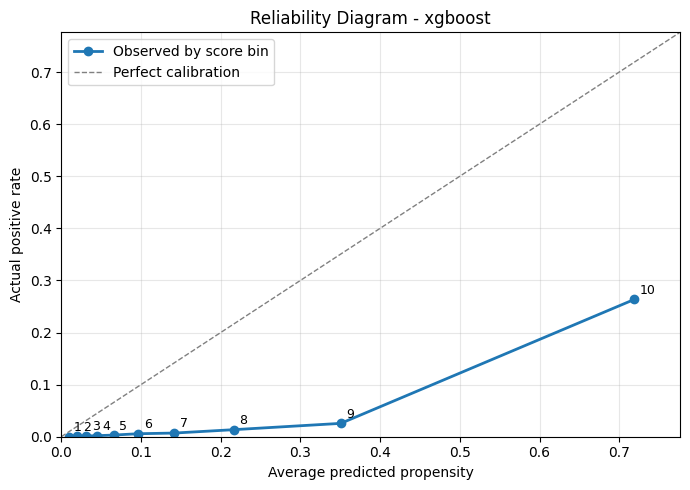

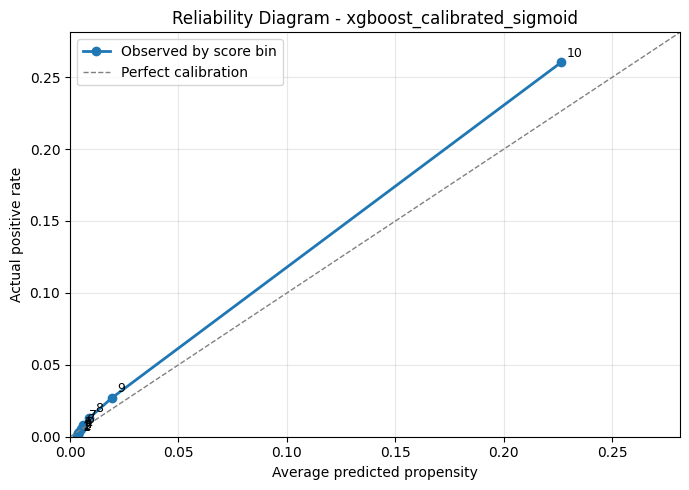

In [10]:
# Ranking, lift, and recommendations use the original selected model scores.
test_scores = best_model.predict_proba(X_test)[:, 1]
test_scored = make_scored_frame(test_df, test_scores, best_model_name)

quality_metrics = pd.DataFrame(evaluate_binary_quality(test_scored))
ranking_metrics = pd.DataFrame(evaluate_ranking(test_scored))
lift_table = pd.DataFrame(evaluate_lift(test_scored))
calibration_bins = pd.DataFrame(evaluate_calibration_bins(test_scored))

quality_metrics.insert(0, 'model', best_model_name)
ranking_metrics.insert(0, 'model', best_model_name)
lift_table.insert(0, 'model', best_model_name)
calibration_bins.insert(0, 'model', best_model_name)

performance_display = (
    quality_metrics.query('PRODUCT_NAME == "ALL"')
    .rename(columns={
        'pr_auc_average_precision': 'PR-AUC',
        'roc_auc': 'ROC-AUC',
        'log_loss': 'Log loss',
    })[['model', 'PR-AUC', 'ROC-AUC', 'Log loss']]
)
k_metrics_display = pd.DataFrame({
    'model': [best_model_name],
    'Hit@1': [float(ranking_metrics.loc[ranking_metrics['k'].eq(1), 'hit_rate_at_k'].iloc[0])],
    'Hit@2': [float(ranking_metrics.loc[ranking_metrics['k'].eq(2), 'hit_rate_at_k'].iloc[0])],
    'Hit@3': [float(ranking_metrics.loc[ranking_metrics['k'].eq(3), 'hit_rate_at_k'].iloc[0])],
    'NDCG@1': [float(ranking_metrics.loc[ranking_metrics['k'].eq(1), 'ndcg_at_k'].iloc[0])],
    'NDCG@2': [float(ranking_metrics.loc[ranking_metrics['k'].eq(2), 'ndcg_at_k'].iloc[0])],
    'NDCG@3': [float(ranking_metrics.loc[ranking_metrics['k'].eq(3), 'ndcg_at_k'].iloc[0])],
    'Lift%20': [float(lift_table.query('PRODUCT_NAME == "ALL" and top_pct == 0.20')['lift_vs_base_rate'].iloc[0])],
})
display(performance_display)
display(k_metrics_display)
display(calibration_bins.query('PRODUCT_NAME == "ALL"').sort_values('score_bin'))
plot_reliability_diagram(
    calibration_bins,
    f'Reliability Diagram - {best_model_name}',
    OUTPUT_DIR / f'gcon_reliability_diagram_{best_model_name}.png',
)

# Calibration is fitted after top-k/ranking evaluation; it is only used to inspect probability calibration.
calibrated_validation_summary = pd.DataFrame()
calibrated_quality_metrics = pd.DataFrame()
calibrated_ranking_metrics = pd.DataFrame()
calibrated_calibration_bins = pd.DataFrame()
calibrated_test_scored = pd.DataFrame()

if CALIBRATE_SELECTED_MODEL:
    calibration_cv = TimeSeriesSplit(n_splits=CALIBRATION_N_SPLITS)
    calibrated_model = CalibratedClassifierCV(
        estimator=best_model,
        method=CALIBRATION_METHOD,
        cv=calibration_cv,
    )
    calibrated_model.fit(X_train, y_train)
    calibrated_model_name = f'{best_model_name}_calibrated_{CALIBRATION_METHOD}'
    calibrated_model_path = MODEL_DIR / f'selected_{best_model_name}_calibrated_{CALIBRATION_METHOD}_model.joblib'
    joblib.dump(calibrated_model, calibrated_model_path)
    saved_models = pd.concat([
        saved_models,
        pd.DataFrame([{
            'model': calibrated_model_name,
            'role': 'selected_calibrated_model',
            'path': str(calibrated_model_path),
            'mean_cv_average_precision': np.nan,
        }]),
    ], ignore_index=True)

    calibrated_validation_summary = pd.DataFrame([
        holdout_metric_row(calibrated_model, calibrated_model_name, X_validation, y_validation, 'validation_calibrated')
    ])
    calibrated_test_scores = calibrated_model.predict_proba(X_test)[:, 1]
    calibrated_test_scored = make_scored_frame(test_df, calibrated_test_scores, calibrated_model_name)
    calibrated_quality_metrics = pd.DataFrame(evaluate_binary_quality(calibrated_test_scored))
    calibrated_ranking_metrics = pd.DataFrame(evaluate_ranking(calibrated_test_scored))
    calibrated_calibration_bins = pd.DataFrame(evaluate_calibration_bins(calibrated_test_scored))
    calibrated_quality_metrics.insert(0, 'model', calibrated_model_name)
    calibrated_ranking_metrics.insert(0, 'model', calibrated_model_name)
    calibrated_calibration_bins.insert(0, 'model', calibrated_model_name)

    calibrated_performance_display = (
        calibrated_quality_metrics.query('PRODUCT_NAME == "ALL"')
        .rename(columns={
            'pr_auc_average_precision': 'PR-AUC',
            'roc_auc': 'ROC-AUC',
            'log_loss': 'Log loss',
        })[['model', 'PR-AUC', 'ROC-AUC', 'Log loss']]
    )
    calibrated_lift_table = pd.DataFrame(evaluate_lift(calibrated_test_scored))
    calibrated_k_metrics_display = pd.DataFrame({
        'model': [calibrated_model_name],
        'Hit@1': [float(calibrated_ranking_metrics.loc[calibrated_ranking_metrics['k'].eq(1), 'hit_rate_at_k'].iloc[0])],
        'Hit@2': [float(calibrated_ranking_metrics.loc[calibrated_ranking_metrics['k'].eq(2), 'hit_rate_at_k'].iloc[0])],
        'Hit@3': [float(calibrated_ranking_metrics.loc[calibrated_ranking_metrics['k'].eq(3), 'hit_rate_at_k'].iloc[0])],
        'NDCG@1': [float(calibrated_ranking_metrics.loc[calibrated_ranking_metrics['k'].eq(1), 'ndcg_at_k'].iloc[0])],
        'NDCG@2': [float(calibrated_ranking_metrics.loc[calibrated_ranking_metrics['k'].eq(2), 'ndcg_at_k'].iloc[0])],
        'NDCG@3': [float(calibrated_ranking_metrics.loc[calibrated_ranking_metrics['k'].eq(3), 'ndcg_at_k'].iloc[0])],
        'Lift%20': [float(calibrated_lift_table.query('PRODUCT_NAME == "ALL" and top_pct == 0.20')['lift_vs_base_rate'].iloc[0])],
    })
    display(calibrated_performance_display)
    display(calibrated_k_metrics_display)
    plot_reliability_diagram(
        calibrated_calibration_bins,
        f'Reliability Diagram - {calibrated_model_name}',
        OUTPUT_DIR / f'gcon_reliability_diagram_{calibrated_model_name}.png',
    )

## 11. SHAP Interpretability

Replace model-native feature importance with SHAP views that explain what the selected model learns overall, how feature values push subscribe propensity up or down, and how drivers differ by product.

,model,feature,mean_abs_shap,mean_shap
0,xgboost,PRODUCT_AFFINITY_AVG,0.832377,-0.651033
1,xgboost,IB_TENURE_MONTHS,0.349116,-0.207141
2,xgboost,SPTC_COUNT_ROLL3_MEAN,0.343099,-0.212509
3,xgboost,AGE_CLEAN,0.243002,-0.131174
4,xgboost,INTEREST_RATE,0.206263,-0.052235
5,xgboost,PRODUCT_AFFINITY_MAX,0.170622,-0.106075
6,xgboost,CUSTOMER_TENURE_MONTHS,0.123903,-0.068466
7,xgboost,PRODUCT_AFFINITY_SUM,0.109533,-0.082853
8,xgboost,ACTIVITY_TYPES_PER_EVENT,0.107997,-0.028128
9,xgboost,AVG_LOAN_AMOUNT,0.107996,-0.042180


,model,feature,mean_abs_shap,mean_shap,value_shap_corr,direction
0,xgboost,PRODUCT_AFFINITY_AVG,0.832376,-0.651032,0.837972,higher value increases propensity
1,xgboost,IB_TENURE_MONTHS,0.349117,-0.207140,-0.844315,higher value decreases propensity
2,xgboost,SPTC_COUNT_ROLL3_MEAN,0.343099,-0.212510,-0.747482,higher value decreases propensity
3,xgboost,AGE_CLEAN,0.243002,-0.131174,0.551147,higher value increases propensity
4,xgboost,INTEREST_RATE,0.206263,-0.052235,-0.809849,higher value decreases propensity
5,xgboost,PRODUCT_AFFINITY_MAX,0.170622,-0.106075,0.755997,higher value increases propensity
6,xgboost,CUSTOMER_TENURE_MONTHS,0.123903,-0.068466,-0.067408,higher value decreases propensity
7,xgboost,PRODUCT_AFFINITY_SUM,0.109533,-0.082853,0.654461,higher value increases propensity
8,xgboost,ACTIVITY_TYPES_PER_EVENT,0.107997,-0.028128,0.675568,higher value increases propensity
9,xgboost,AVG_LOAN_AMOUNT,0.107996,-0.042180,0.589430,higher value increases propensity


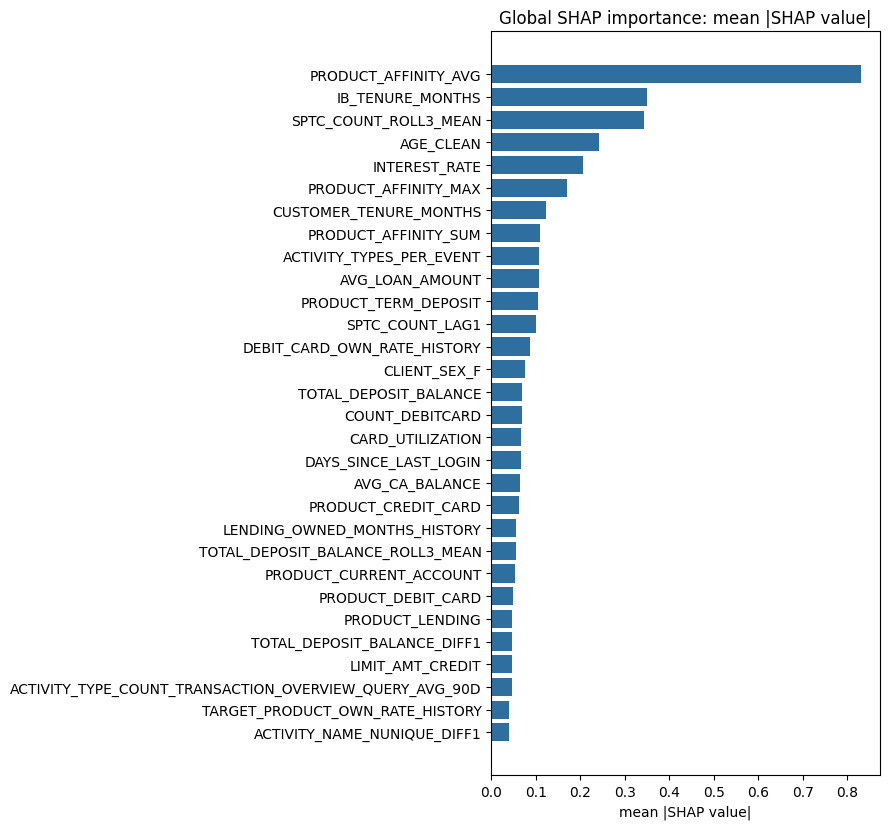

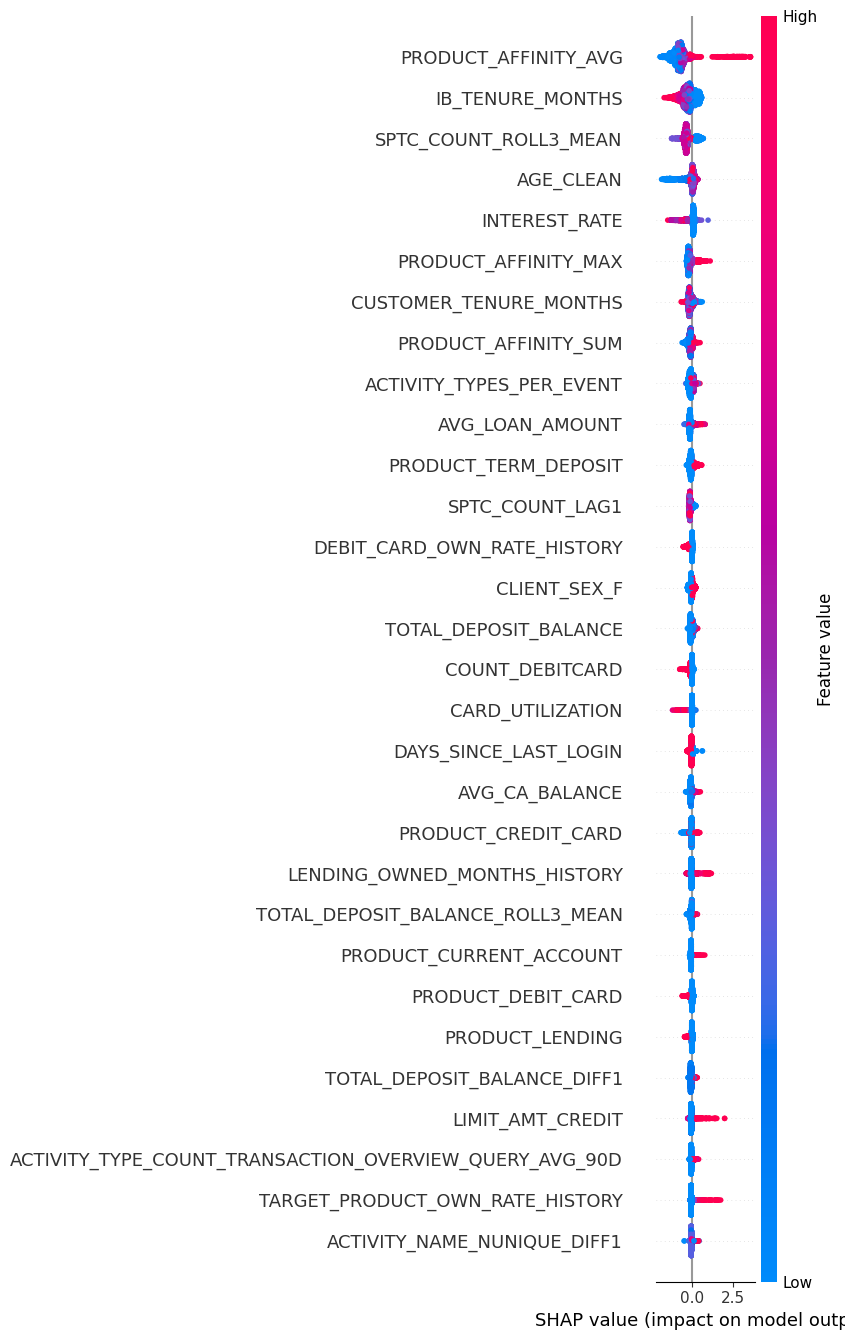

,model,product_name,feature,mean_abs_shap,mean_shap,n_rows
0,xgboost,CREDIT_CARD,PRODUCT_AFFINITY_AVG,0.779146,-0.779146,1283
1,xgboost,CREDIT_CARD,IB_TENURE_MONTHS,0.313135,-0.148651,1283
2,xgboost,CREDIT_CARD,SPTC_COUNT_ROLL3_MEAN,0.312745,-0.170799,1283
3,xgboost,CREDIT_CARD,AGE_CLEAN,0.285539,-0.158997,1283
4,xgboost,CREDIT_CARD,PRODUCT_AFFINITY_MAX,0.164277,-0.145660,1283
5,xgboost,CREDIT_CARD,PRODUCT_AFFINITY_SUM,0.136566,-0.100426,1283
6,xgboost,CREDIT_CARD,AVG_LOAN_AMOUNT,0.135870,-0.044012,1283
7,xgboost,CREDIT_CARD,CUSTOMER_TENURE_MONTHS,0.129110,-0.069900,1283
8,xgboost,CREDIT_CARD,INTEREST_RATE,0.125328,0.023903,1283
9,xgboost,CREDIT_CARD,DEBIT_CARD_OWN_RATE_HISTORY,0.105756,-0.068095,1283


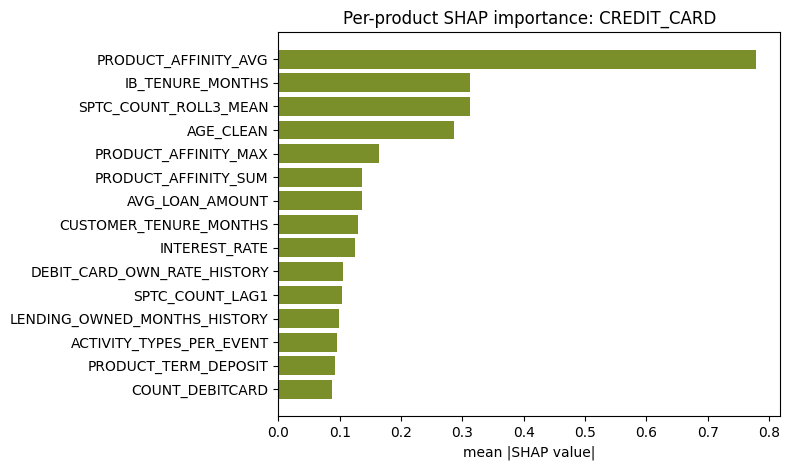

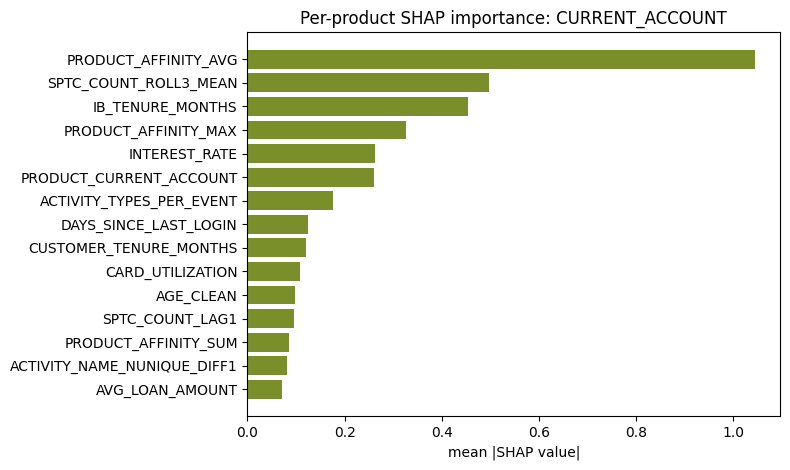

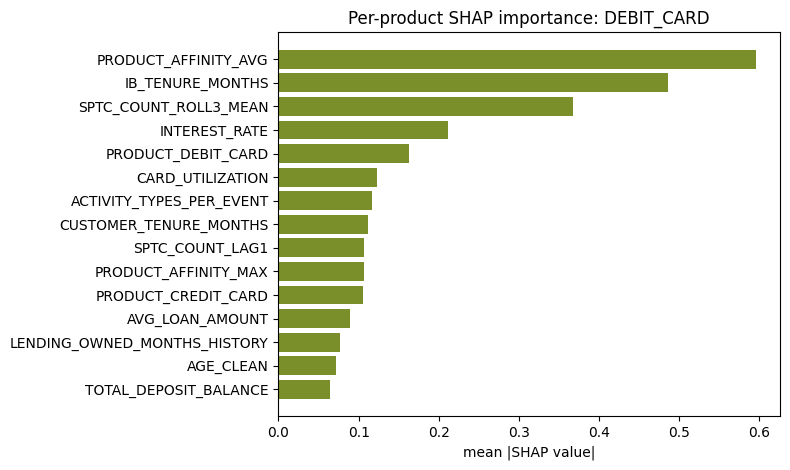

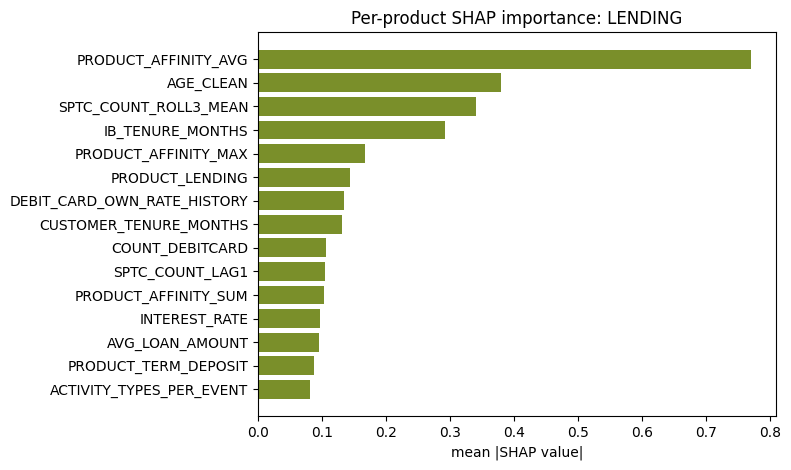

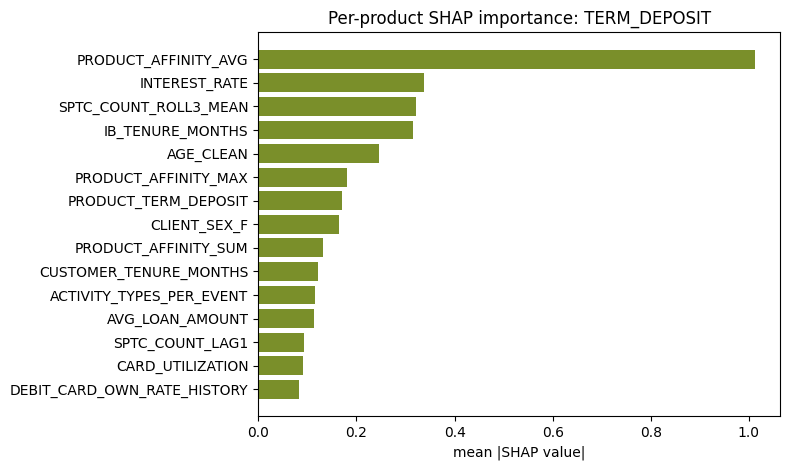

In [11]:
shap_product_importance = pd.DataFrame(columns=['model', 'product_name', 'feature', 'mean_abs_shap', 'mean_shap', 'n_rows'])
feature_direction = pd.DataFrame(columns=['model', 'feature', 'mean_abs_shap', 'mean_shap', 'value_shap_corr', 'direction'])

try:
    import shap

    shap_sample = X_test.sample(n=min(SHAP_SAMPLE_SIZE, len(X_test)), random_state=RANDOM_STATE)
    shap_sample = shap_sample[feature_cols]
    shap_context = test_df.loc[shap_sample.index, ['PRODUCT_NAME']].reset_index(drop=True)

    explainer = shap.TreeExplainer(best_model)
    raw_shap_values = explainer.shap_values(shap_sample)

    def select_positive_class_shap(values):
        if isinstance(values, list):
            return np.asarray(values[-1])
        values = np.asarray(values)
        if values.ndim == 3:
            if values.shape[2] == 2:
                return values[:, :, 1]
            if values.shape[0] == 2:
                return values[1]
            return values[:, :, -1]
        return values

    shap_values = select_positive_class_shap(raw_shap_values)
    shap_values_df = pd.DataFrame(shap_values, columns=feature_cols, index=shap_sample.index)

    shap_importance = (
        pd.DataFrame({
            'model': best_model_name,
            'feature': feature_cols,
            'mean_abs_shap': np.abs(shap_values).mean(axis=0),
            'mean_shap': shap_values.mean(axis=0),
        })
        .sort_values('mean_abs_shap', ascending=False)
        .reset_index(drop=True)
    )
    feature_importance = shap_importance.rename(columns={'mean_abs_shap': 'importance'})[
        ['model', 'feature', 'importance']
    ].copy()

    corr_rows = []
    for feature in feature_cols:
        feature_values = shap_sample[feature].to_numpy(dtype='float64')
        feature_shap = shap_values_df[feature].to_numpy(dtype='float64')
        if np.nanstd(feature_values) == 0 or np.nanstd(feature_shap) == 0:
            corr = np.nan
        else:
            corr = np.corrcoef(feature_values, feature_shap)[0, 1]
        if pd.isna(corr):
            direction = 'flat / unclear'
        elif corr > 0:
            direction = 'higher value increases propensity'
        else:
            direction = 'higher value decreases propensity'

        corr_rows.append({
            'model': best_model_name,
            'feature': feature,
            'mean_abs_shap': np.abs(feature_shap).mean(),
            'mean_shap': feature_shap.mean(),
            'value_shap_corr': corr,
            'direction': direction,
        })
    feature_direction = (
        pd.DataFrame(corr_rows)
        .sort_values('mean_abs_shap', ascending=False)
        .reset_index(drop=True)
    )

    display(shap_importance.head(50))
    display(feature_direction.head(50))

    top_n = min(30, len(shap_importance))
    plot_df = shap_importance.head(top_n).sort_values('mean_abs_shap')
    fig, ax = plt.subplots(figsize=(9, max(6, top_n * 0.28)))
    ax.barh(plot_df['feature'], plot_df['mean_abs_shap'], color='#2f6f9f')
    ax.set_title('Global SHAP importance: mean |SHAP value|')
    ax.set_xlabel('mean |SHAP value|')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

    shap.summary_plot(shap_values, shap_sample, max_display=30, plot_type='dot', show=True)

    product_frames = []
    for product_name, product_index in shap_context.groupby('PRODUCT_NAME', sort=True).groups.items():
        product_shap = shap_values[list(product_index), :]
        product_frames.append(pd.DataFrame({
            'model': best_model_name,
            'product_name': product_name,
            'feature': feature_cols,
            'mean_abs_shap': np.abs(product_shap).mean(axis=0),
            'mean_shap': product_shap.mean(axis=0),
            'n_rows': len(product_index),
        }))

    if product_frames:
        shap_product_importance = (
            pd.concat(product_frames, ignore_index=True)
            .sort_values(['product_name', 'mean_abs_shap'], ascending=[True, False])
            .reset_index(drop=True)
        )

    display(shap_product_importance.groupby('product_name').head(15).reset_index(drop=True))

    for product_name in sorted(shap_product_importance['product_name'].dropna().unique()):
        product_plot = (
            shap_product_importance[shap_product_importance['product_name'].eq(product_name)]
            .head(15)
            .sort_values('mean_abs_shap')
        )
        fig, ax = plt.subplots(figsize=(8, 4.8))
        ax.barh(product_plot['feature'], product_plot['mean_abs_shap'], color='#7a8f2a')
        ax.set_title(f'Per-product SHAP importance: {product_name}')
        ax.set_xlabel('mean |SHAP value|')
        ax.set_ylabel('')
        plt.tight_layout()
        plt.show()

except Exception as exc:
    shap_importance = pd.DataFrame(columns=['model', 'feature', 'mean_abs_shap', 'mean_shap'])
    feature_importance = pd.DataFrame(columns=['model', 'feature', 'importance'])
    shap_product_importance = pd.DataFrame(columns=['model', 'product_name', 'feature', 'mean_abs_shap', 'mean_shap', 'n_rows'])
    feature_direction = pd.DataFrame(columns=['model', 'feature', 'mean_abs_shap', 'mean_shap', 'value_shap_corr', 'direction'])
    print('SHAP skipped:', type(exc).__name__, exc)

## 12. Recommendations

Keep the highest-propensity product per customer-month in the test window.

In [12]:
recommendations = (
    test_scored
    .sort_values(['CUSTOMER_NUMBER', 'MONTH', 'SUBSCRIPTION_PROPENSITY'], ascending=[True, True, False])
    .groupby(['CUSTOMER_NUMBER', 'MONTH'], as_index=False)
    .head(1)
    .reset_index(drop=True)
)
display(recommendations.head(20))

,CUSTOMER_NUMBER,PRODUCT_CODE,PRODUCT_NAME,MONTH,SUBSCRIPTION,SUBSCRIPTION_PROPENSITY,MODEL
0,0,102,TERM_DEPOSIT,2019-10-31,0,0.176441,xgboost
1,3,102,TERM_DEPOSIT,2019-10-31,0,0.075951,xgboost
2,9,103,CREDIT_CARD,2019-10-31,0,0.675723,xgboost
3,13,101,CURRENT_ACCOUNT,2019-10-31,0,0.914294,xgboost
4,14,101,CURRENT_ACCOUNT,2019-10-31,0,0.094348,xgboost
5,15,102,TERM_DEPOSIT,2019-10-31,0,0.387993,xgboost
6,32,102,TERM_DEPOSIT,2019-10-31,0,0.043868,xgboost
7,37,102,TERM_DEPOSIT,2019-10-31,0,0.037920,xgboost
8,44,103,CREDIT_CARD,2019-10-31,1,0.786022,xgboost
9,51,101,CURRENT_ACCOUNT,2019-10-31,1,0.953032,xgboost


## 13. Save Outputs

Persist CV results, validation metrics, test scores, metrics, recommendations, and feature importance.

In [13]:
cv_summary['best_params'] = cv_summary['best_params'].astype(str)
safe_to_csv(cv_summary, OUTPUT_DIR / 'gcon_randomsearch_cv_summary.csv')
safe_to_csv(cv_results, OUTPUT_DIR / 'gcon_randomsearch_cv_results.csv')
safe_to_csv(validation_model_comparison, OUTPUT_DIR / 'gcon_validation_model_comparison.csv')
safe_to_csv(validation_summary, OUTPUT_DIR / 'gcon_validation_metrics.csv')
safe_to_csv(calibrated_validation_summary, OUTPUT_DIR / 'gcon_calibrated_validation_metrics.csv')
safe_to_csv(saved_models, OUTPUT_DIR / 'gcon_saved_models.csv')
safe_to_csv(quality_metrics, OUTPUT_DIR / 'gcon_test_quality_metrics.csv')
safe_to_csv(ranking_metrics, OUTPUT_DIR / 'gcon_test_ranking_metrics.csv')
safe_to_csv(lift_table, OUTPUT_DIR / 'gcon_test_lift_table.csv')
safe_to_csv(calibration_bins, OUTPUT_DIR / 'gcon_test_calibration_bins.csv')
safe_to_csv(calibrated_quality_metrics, OUTPUT_DIR / 'gcon_calibrated_test_quality_metrics.csv')
safe_to_csv(calibrated_ranking_metrics, OUTPUT_DIR / 'gcon_calibrated_test_ranking_metrics.csv')
safe_to_csv(calibrated_calibration_bins, OUTPUT_DIR / 'gcon_calibrated_test_calibration_bins.csv')
safe_to_csv(feature_importance, OUTPUT_DIR / 'gcon_feature_importance.csv')
safe_to_csv(shap_importance, OUTPUT_DIR / 'gcon_shap_importance.csv')
safe_to_csv(shap_product_importance, OUTPUT_DIR / 'gcon_shap_product_importance.csv')

save_table(test_scored, f'gcon_test_scores_best_{best_model_name}')
if len(calibrated_test_scored):
    save_table(calibrated_test_scored, f'gcon_test_scores_best_{best_model_name}_calibrated_{CALIBRATION_METHOD}')
save_table(recommendations, f'gcon_recommendations_best_{best_model_name}')

print('best model:', best_model_name)
print('ranking model:', best_model_name)

saved c:\Users\Admin\Desktop\gcon\train_NBFO_IB\saved_models\gcon_randomsearch_cv_summary.csv (2, 4)
saved c:\Users\Admin\Desktop\gcon\train_NBFO_IB\saved_models\gcon_randomsearch_cv_results.csv (24, 25)
saved c:\Users\Admin\Desktop\gcon\train_NBFO_IB\saved_models\gcon_validation_model_comparison.csv (2, 10)
saved c:\Users\Admin\Desktop\gcon\train_NBFO_IB\saved_models\gcon_validation_metrics.csv (1, 9)
saved c:\Users\Admin\Desktop\gcon\train_NBFO_IB\saved_models\gcon_calibrated_validation_metrics.csv (1, 9)
saved c:\Users\Admin\Desktop\gcon\train_NBFO_IB\saved_models\gcon_saved_models.csv (4, 4)
saved c:\Users\Admin\Desktop\gcon\train_NBFO_IB\saved_models\gcon_test_quality_metrics.csv (6, 10)
saved c:\Users\Admin\Desktop\gcon\train_NBFO_IB\saved_models\gcon_test_ranking_metrics.csv (3, 15)
saved c:\Users\Admin\Desktop\gcon\train_NBFO_IB\saved_models\gcon_test_lift_table.csv (24, 12)
saved c:\Users\Admin\Desktop\gcon\train_NBFO_IB\saved_models\gcon_test_calibration_bins.csv (60, 8)
save